Dataset
----

In [53]:
import warnings
warnings.filterwarnings("ignore")

In [54]:
from sklearn.preprocessing   import OneHotEncoder
from sklearn.datasets        import fetch_20newsgroups
from sklearn.metrics         import classification_report
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np

from collections import Counter
from tqdm import tqdm
from math import floor

from nltk.tokenize import sent_tokenize, word_tokenize, RegexpTokenizer

from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import torch.nn as nn
import torch
torch.manual_seed(seed = 42)
device =  torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


In [55]:
@torch.no_grad()
def eval_model(model, device, data_loader, target_names = False):
    model.eval()
    all_pred   = torch.empty((0,), dtype = torch.float32).to(device)
    all_labels = torch.empty((0,), dtype = torch.float32).to(device)

    for data_inputs, data_labels in data_loader:
        data_inputs = data_inputs.to(device)
        data_labels = data_labels.to(device)
        preds,_ = model(data_inputs)
        pred_labels = F.one_hot(preds.argmax(dim = 1),num_classes=3)

        all_pred   = torch.cat((all_pred,pred_labels), dim = 0 )
        all_labels = torch.cat((all_labels,data_labels))
    print(classification_report(y_pred =   all_pred.cpu().numpy(), y_true = all_labels.cpu().numpy(),  target_names  = target_names, zero_division = 0))

In [56]:
newsgroups_train = fetch_20newsgroups(data_home = '/home/drew/Split-Learning/Data',
                                      subset    = 'all',
                                      download_if_missing = True,
                                      remove    = ('headers', 'footers', 'quotes'),
                                      categories= ['rec.motorcycles','rec.sport.baseball','sci.space'])

X, Y = newsgroups_train.data, newsgroups_train.target
print(len(X))
print(Y.shape)

2977
(2977,)


In [57]:
from gensim.models import Word2Vec
from nltk.corpus import stopwords
#import gensim
"""
[nltk_data] Downloading package punkt_tab to /home/drew/nltk_data...
[nltk_data] Package punkt_tab is already up-to-date!
"""
tokenizer = RegexpTokenizer(r'\w+')

In [58]:
def tokenize_document(sample):
    return [word.lower() for word in tokenizer.tokenize(sample) if len(word) > 1 and word not in stopwords.words('english')]

tok_words = [tokenize_document(document) for document in X]

In [59]:
# Remove the Y samples that are filtered out
indices = [idx for idx, document in enumerate(tok_words) if len(document) > 0]
Y = Y[indices]

words   = [document for document in tok_words if len(document) > 0]

In [60]:
doc_lengths = [len(doc) for doc in words]
# Counter(doc_lengths)
word_model = Word2Vec(sentences=words, vector_size = 200, window=3, min_count=1, workers=4)
vocabular_size = len(word_model.wv.index_to_key)
#word_model.wv.most_similar('science') -> Shows great results

In [61]:
example_word = words[0][0]
print(example_word)
print(word_model.wv[example_word][:3]) # Obtain via
ex_idx = word_model.wv.key_to_index[example_word]
print(ex_idx)
print(word_model.wv.vectors[ex_idx][:3])

index_words = [[word_model.wv.key_to_index[word] for word in document] for document in words]
print(index_words[0][:5] )# -> 3053, 29,5532, 7363,6820

wednesday
[ 0.04249991 -0.01264728  0.00566792]
3053
[ 0.04249991 -0.01264728  0.00566792]
[3053, 29, 5532, 7363, 6820]


In [62]:
# embed_weights = word_model.wv.vectors
#embed_layer = nn.Embedding.from_pretrained(torch.from_numpy(embed_weights), padding_idx=vocab_size)
#embed_layer.weight[ex_idx][:3]

----


In [63]:
# embed_layer.weight[vocab_size]

---

In [64]:
vocab_size, embed_size =  word_model.wv.vectors.shape

def padding_trunc(row):
    MIN_TOKEN_LEN = 500
    row = torch.Tensor(row)
    # If its smaller we need to truncate
    if len(row) > MIN_TOKEN_LEN:
        return row[:MIN_TOKEN_LEN]
    # Otherwise we pad it with vocab_size
    return F.pad(row, pad=(0, MIN_TOKEN_LEN - len(row)), mode='constant', value = vocab_size) # Vocab_Size is a global variable in this case

In [65]:
enc_words = np.array([padding_trunc(document) for document in index_words])
enc_words = torch.Tensor(enc_words).long()
enc_words.shape

torch.Size([2878, 500])

In [66]:
print(len(index_words[0]))
enc_words[0][:45]

44


tensor([ 3053,    29,  5532,  7363,  6820,   298, 11053,  1295,   130,  8012,
         1115,   130, 10950,   130,  5532,  6820,   222,   130,   130, 14637,
        10987,  1761,   152,  3950,  2575,  2139,  8781, 10698,  7266, 10655,
        11714,  2267,  8012,  1115,   522,  5798,   647,  4586,  5532,  6820,
          395, 11678, 11690,   542, 25866])

----

In [67]:
enc = OneHotEncoder(handle_unknown='ignore', sparse_output = False)
Y = enc.fit_transform(Y.reshape(-1, 1)) # Should be (sampeles, 3)
print(Y.shape)
print(Y[0])

(2878, 3)
[0. 1. 0.]


X and Y are in the proper format for training.
- X instance is [3517, 2508, 12860, 13501, 5368, 5323, 12814, 12048, 8771, 11984] 
- Y instance is [0. 1. 0.]

In [68]:
enc_words.shape

torch.Size([2878, 500])

In [69]:
Y.shape

(2878, 3)

In [70]:
#X = X.reshape(samples,seq_len)
X_train, X_test, Y_train, Y_test = train_test_split(enc_words.numpy(),Y, test_size = 0.2,random_state = 42) 

X_train = torch.from_numpy(X_train).long()
Y_train = torch.from_numpy(Y_train).type(torch.float32)

X_test  = torch.from_numpy(X_test) .long()
Y_test  = torch.from_numpy(Y_test) .type(torch.float32)

training_dataset = TensorDataset(X_train,Y_train)
testing_dataset  = TensorDataset(X_test ,Y_test )

train_loader = DataLoader(TensorDataset(X_train,Y_train) , batch_size = X_train.shape[0], shuffle = False)
test_loader  = DataLoader(TensorDataset(X_test ,Y_test ) , batch_size = X_test.shape[0] , shuffle = False)

In [71]:
def train_model(model,device, optimizer ,data_loader, loss_module, num_epochs=100):
    model.train()
    train_losses  = []
    for epoch in tqdm(range(num_epochs), colour='BLUE'):
        epoch_loss = 0.0
        for data_inputs, data_labels in data_loader:
            # Put training data into GPU
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.type(torch.float32).to(device)

            preds, alpha = model(data_inputs)
            preds = preds.type(torch.float32).to(device)
            
            loss  = loss_module(preds, data_labels)
            epoch_loss += loss.item()
            train_losses.append(loss.item())

            # Zero the gradients
            optimizer.zero_grad()
            loss     .backward()
            optimizer.step()
        epoch_loss /= len(data_loader)

    return train_losses

In [72]:
vocab_size, embed_size = word_model.wv.vectors.shape
embed_table   = torch.from_numpy(word_model.wv.vectors).type(torch.float32)
# Add the padding entry within our embedding table
padding_idx   = torch.zeros((1,embed_size))
embed_weights = torch.concat([embed_table,padding_idx],dim = 0)

In [91]:
class Net(nn.Module):
    def __init__(self, embed_weights, vocab_size, label_space, embed_d, num_of_filters, kernel_size):
        super().__init__()
        #self.embed = nn.Embedding(num_embeddings = num_of_words ,embedding_dim=embed_d, padding_idx=0)
        self.embed = nn.Embedding.from_pretrained(embed_weights, padding_idx=vocab_size)
        self.conv  = nn.Conv1d(embed_d, num_of_filters, kernel_size = kernel_size, padding = int(floor(kernel_size//2)))
        self.U     = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)
        # self.embed_drop = nn.Dropout(p = 0.5)

    def forward(self, x):
        x = self.embed (x)
        # x = self.embed_drop(x)
        x = x.transpose (1, 2)
        #apply convolution and nonlinearity (tanh)
        x = F. tanh(self.conv(x).transpose(1,2))
        #apply attention
        alpha = F.softmax(self.U.weight.matmul(x. transpose (1,2)) , dim=2)
        #document representations are weighted sums using the attention. Can compute all at once as a matmul
        m = alpha.matmul(x)
        #Final layer classification
        y = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)
        return y, alpha


model = Net(embed_weights = embed_weights,
            vocab_size          = vocab_size,
            num_of_filters = 10,
            label_space    = 3, 
            kernel_size    = 3,
            embed_d        = embed_size)
model.to(device=device)


Net(
  (embed): Embedding(25867, 200, padding_idx=25866)
  (conv): Conv1d(200, 10, kernel_size=(3,), stride=(1,), padding=(1,))
  (U): Linear(in_features=10, out_features=3, bias=True)
  (final): Linear(in_features=10, out_features=3, bias=True)
)

In [92]:
eval_model(model        = model,
           device       = device,
           data_loader  = train_loader,
           target_names = ['rec.motorcycles','rec.sport.baseball','sci.space'])

eval_model(model        = model,
           device       = device,
           data_loader  = test_loader,
           target_names = ['rec.motorcycles','rec.sport.baseball','sci.space'])

                    precision    recall  f1-score   support

   rec.motorcycles       0.00      0.00      0.00       770
rec.sport.baseball       1.00      0.01      0.02       768
         sci.space       0.33      1.00      0.50       764

         micro avg       0.33      0.33      0.33      2302
         macro avg       0.44      0.34      0.17      2302
      weighted avg       0.44      0.33      0.17      2302
       samples avg       0.33      0.33      0.33      2302

                    precision    recall  f1-score   support

   rec.motorcycles       0.00      0.00      0.00       199
rec.sport.baseball       0.00      0.00      0.00       187
         sci.space       0.33      1.00      0.50       190

         micro avg       0.33      0.33      0.33       576
         macro avg       0.11      0.33      0.17       576
      weighted avg       0.11      0.33      0.16       576
       samples avg       0.33      0.33      0.33       576



In [93]:
loss_module = torch.nn.BCEWithLogitsLoss()
#optimizer  = torch.optim.SGD(model.parameters(), lr = 0.1, momentum = 0.9)
optimizer   = torch.optim.Adam(model.parameters(), lr=0.01, betas =  (0.9,0.99)) #(0.1,0.3)

# saved_param = torch.load(f = '/home/drew/Split-Learning/ScratchWork/model.tar')
# model.load_state_dict(saved_param)

hist = train_model(model       = model,
                   device      = device,
                   optimizer   = optimizer,
                   data_loader = train_loader,
                   loss_module = loss_module,
                   num_epochs  = 2000)

100%|██████████| 2000/2000 [01:31<00:00, 21.91it/s]


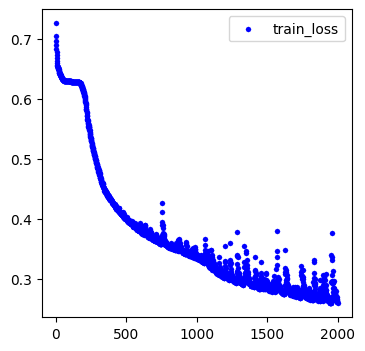

In [95]:
plt.figure(figsize=(4,4))
plt.scatter(y = hist,

            x = [_ for _ in range(len(hist))],
            alpha = 1, lw = 0.1, c = 'b', s = 14, label = 'train_loss')
plt.legend()
plt.show()

In [96]:
eval_model(model        = model,
           device       = device,
           data_loader  = train_loader,
           target_names = ['rec.motorcycles','rec.sport.baseball','sci.space'])

eval_model(model        = model,
           device       = device,
           data_loader  = test_loader,
           target_names = ['rec.motorcycles','rec.sport.baseball','sci.space'])

#torch.save(model.state_dict(),f = '/home/drew/Split-Learning/ScratchWork/model.tar')

                    precision    recall  f1-score   support

   rec.motorcycles       0.70      0.90      0.79       770
rec.sport.baseball       0.89      0.83      0.86       768
         sci.space       0.96      0.75      0.84       764

         micro avg       0.83      0.83      0.83      2302
         macro avg       0.85      0.83      0.83      2302
      weighted avg       0.85      0.83      0.83      2302
       samples avg       0.83      0.83      0.83      2302

                    precision    recall  f1-score   support

   rec.motorcycles       0.65      0.84      0.73       199
rec.sport.baseball       0.84      0.78      0.81       187
         sci.space       0.91      0.69      0.79       190

         micro avg       0.77      0.77      0.77       576
         macro avg       0.80      0.77      0.77       576
      weighted avg       0.80      0.77      0.77       576
       samples avg       0.77      0.77      0.77       576



---

## Visualizing the importance of words

In [78]:
sampling_dataset   = DataLoader(TensorDataset(X_train,Y_train) , batch_size = 10, shuffle = False)
X_sample, Y_sample = next(iter(sampling_dataset))
(X_sample.shape, Y_sample.shape)

(torch.Size([10, 500]), torch.Size([10, 3]))

In [79]:
# Obtain our trained model
model.eval()

Net(
  (embed): Embedding(25867, 200, padding_idx=25866)
  (conv): Conv1d(200, 10, kernel_size=(3,), stride=(1,), padding=(1,))
  (U): Linear(in_features=10, out_features=3, bias=True)
  (final): Linear(in_features=10, out_features=3, bias=True)
)

## Extract a single instance and map out the attnmap for each label

In [80]:
model.to(torch.device('cpu'))

Net(
  (embed): Embedding(25867, 200, padding_idx=25866)
  (conv): Conv1d(200, 10, kernel_size=(3,), stride=(1,), padding=(1,))
  (U): Linear(in_features=10, out_features=3, bias=True)
  (final): Linear(in_features=10, out_features=3, bias=True)
)

In [81]:
x = model.embed (X_sample)
print("Embedding Shape: ",x.shape)
x = x.transpose (1, 2)
print("Transposing After Embedding",x.shape)
#apply convolution and nonlinearity (tanh)
x = F. tanh(model.conv(x).transpose(1,2))
print("Transpose after convultion",x.shape)
#apply attention
alpha = F.softmax(model.U.weight.matmul(x. transpose (1,2)) , dim=2)
print("Attn Map Shape: ",alpha.shape)
#document representations are weighted sums using the attention. Can compute all at once as a matmul
m = alpha.matmul(x)
print("Value multiplied by attn",m.shape)
#Final layer classification
y = model.final.weight.mul(m).sum(dim=2).add(model.final.bias)
print("Model Output shape: ",y.shape)

Embedding Shape:  torch.Size([10, 500, 200])
Transposing After Embedding torch.Size([10, 200, 500])
Transpose after convultion torch.Size([10, 500, 10])
Attn Map Shape:  torch.Size([10, 3, 500])
Value multiplied by attn torch.Size([10, 3, 10])
Model Output shape:  torch.Size([10, 3])


Predicted = rec.motorcycles
Distribution: tensor([[-0.1888, -1.0737, -1.1894]], grad_fn=<AddBackward0>)


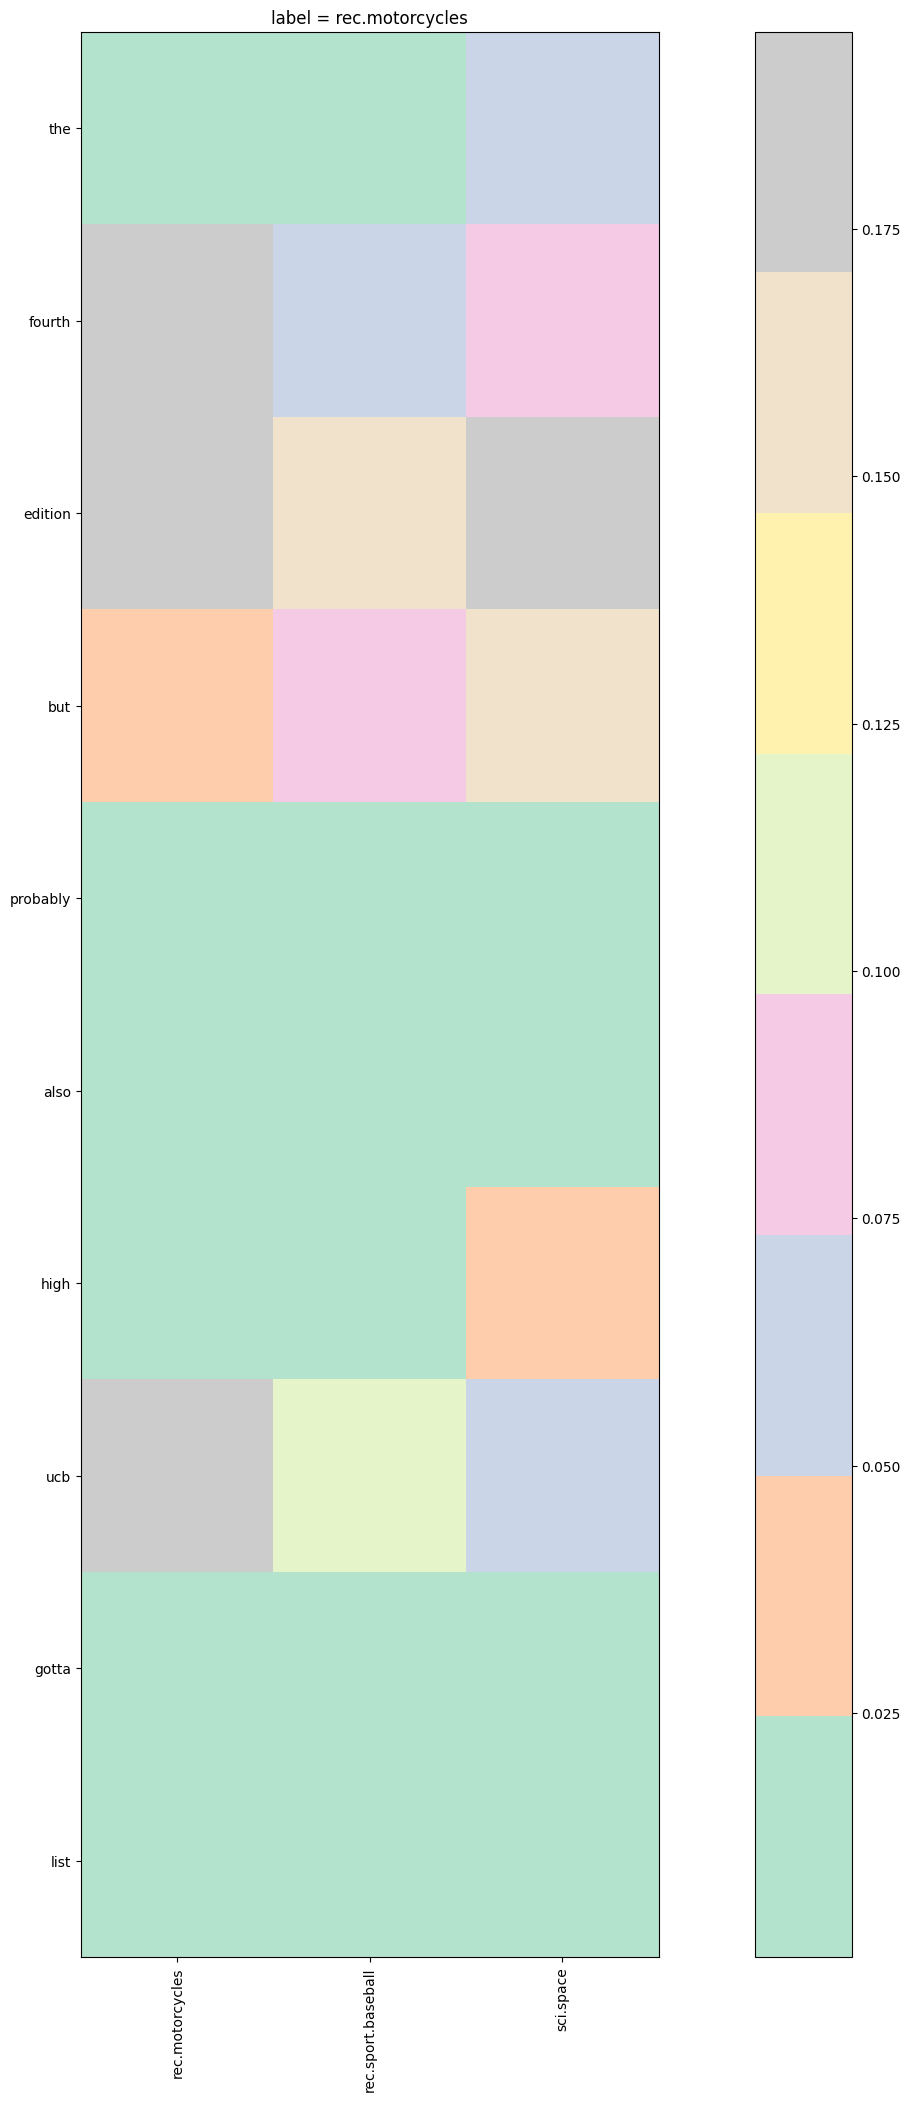

In [90]:
instance = 8
X_s = X_sample[instance].unsqueeze(dim = 0)
Y_s = Y_sample[instance].unsqueeze(dim = 0)
x   = model.embed (X_s)
x   = x.transpose (1, 2)
x   = F.tanh(model.conv(x).transpose(1,2))
alpha = F.softmax(model.U.weight.matmul(x.transpose (1,2)) , dim=2)
m   = alpha.matmul(x)
y   = model.final.weight.mul(m).sum(dim=2).add(model.final.bias)

sample_words = np.array([word_model.wv.index_to_key[int(w)] for w in X_s.flatten() if int(w) < vocab_size])

# Model our attn map for our dataeu
target_names = ['rec.motorcycles','rec.sport.baseball','sci.space']

plt.figure(figsize=(25,25))
plt.title(label = f'label = {target_names[Y_s.argmax(dim = 1)]}' )
print(f'Predicted = {target_names[y.argmax(dim = 1)]}')
print(f'Distribution: {y}')
plt.imshow(alpha.squeeze(dim=0).T.detach().numpy()[:len(sample_words)], # We select only the words and remove the padding
           cmap='Pastel2')

plt.yticks(ticks = [_ for _ in range(len(sample_words))], labels = sample_words,rotation = 0)
plt.xticks(ticks = [_ for _ in range(len(target_names))], labels = target_names,rotation = 90)

plt.colorbar()
plt.show()